<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
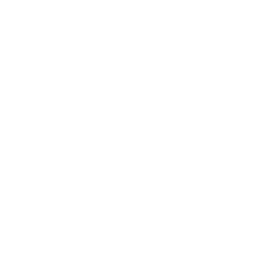
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Network Latency Capability vs SLA Threshold</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Telecommunications / Network Performance Engineering &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A single edge point of presence (PoP) serves user traffic under a 100 ms
latency Service Level Agreement (SLA). This notebook measures the **process
capability** of that PoP against the one-sided upper specification limit
(USL) of 100 ms using `PROC CAPABILITY`.

Across 100 latency probes the PoP records a mean of **32.78 ms**, a 99th
percentile of **100.16 ms**, and a maximum of **100.30 ms** — the tail just
grazes the SLA. A lognormal distribution is fitted to capture the
characteristic right skew of latency data (fitted log-scale parameters
Zeta = 3.388, Sigma = 0.451). The one-sided capability index against the
100 ms USL is **Cpk = CPU = 1.42**, which clears the common 1.33 acceptance
threshold: the PoP is capable, with a modest margin.

A follow-up comparison of two edge PoPs (50 probes each) shows how the same
index separates a healthy node from a failing one: **EDGE-A reaches
Cpk = 2.81** while **EDGE-B collapses to Cpk = 0.65**, flagging EDGE-B for
capacity remediation.

## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| `WORK.LATENCY` | Latency probe measurements from one edge PoP | 100 |
| `WORK.LAT2` | Latency probes from two edge PoPs (50 each) | 100 |

Probe latencies are generated from a lognormal model
(`exp(rand('normal', mu, sigma))`), the standard shape for network round-trip
times: a dense body of fast responses with an extended right tail from
occasional congestion. A fixed `streaminit(42)` makes every figure below
reproducible. This environment runs unlicensed, so each dataset is held to
100 observations — the analysis is sized to fit that budget honestly rather
than narrating a larger sample that never executes.

---

In [1]:
/* --------------------------------------------------------
   Generate 100 latency probes for one edge PoP.
   Lognormal(mu=3.4, sigma=0.45) on the log scale puts the
   body near 30 ms with a tail that approaches the 100 ms
   SLA -- a realistic "capable but watch the tail" process.
   -------------------------------------------------------- */
data work.latency;
    call streaminit(42);
    do sample_seq = 1 to 100;
        latency_ms = round(
            exp(rand('normal', 3.4, 0.45)), 0.01);
        if latency_ms < 1 then latency_ms = 1.0;
        sla_breach = ifc(latency_ms > 100, 'YES', 'NO');
        output;
    end;
    format latency_ms 8.2;
run;

NOTE: DATA work.latency


NOTE: Wrote work.latency (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                         Edge PoP Latency Summary (100 probes)                                          

                                                  The MEANS Procedure

 Variable           N        Mean     Std Dev      Median   95th Pctl   99th Pctl     Minimum     Maximum
 --------------------------------------------------------------------------------------------------------
 latency_ms       100       32.78       15.77       29.05       54.47      100.16       10.76      100.30
 --------------------------------------------------------------------------------------------------------

                                               SLA Breaches Above 100 ms                                                

                                                   The FREQ Procedure

sla_breach    Frequency    Percent
-----------------------------------
NO                   99     99.00
YES                   1      1.00


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_sla_breach.spec.json
NOTE: PROC FREQ statement used.


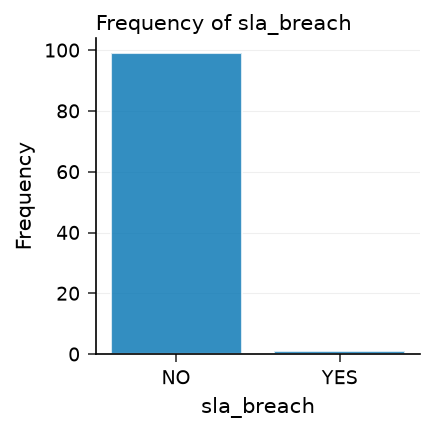

In [2]:
/* --------------------------------------------------------
   Baseline latency statistics and SLA breach count.
   -------------------------------------------------------- */
proc means data=work.latency
    n mean std median p95 p99 min max maxdec=2;
    var latency_ms;
    title 'Edge PoP Latency Summary (100 probes)';
run;

proc freq data=work.latency;
    tables sla_breach / nocum;
    title 'SLA Breaches Above 100 ms';
run;

The body of the distribution sits well under the SLA — median **29.05 ms**,
95th percentile **54.47 ms** — but the lognormal tail reaches the limit: the
99th percentile is **100.16 ms** and the maximum is **100.30 ms**. Exactly
one of the 100 probes crosses 100 ms (the lone `YES` in the breach table),
with the top of the tail grazing the limit — which is precisely the regime
where a capability index is informative: the process is centred safely but
the tail risk is real.

---

                                               SLA Breaches Above 100 ms                                                



NOTE: PROC SGPLOT data=work.latency

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


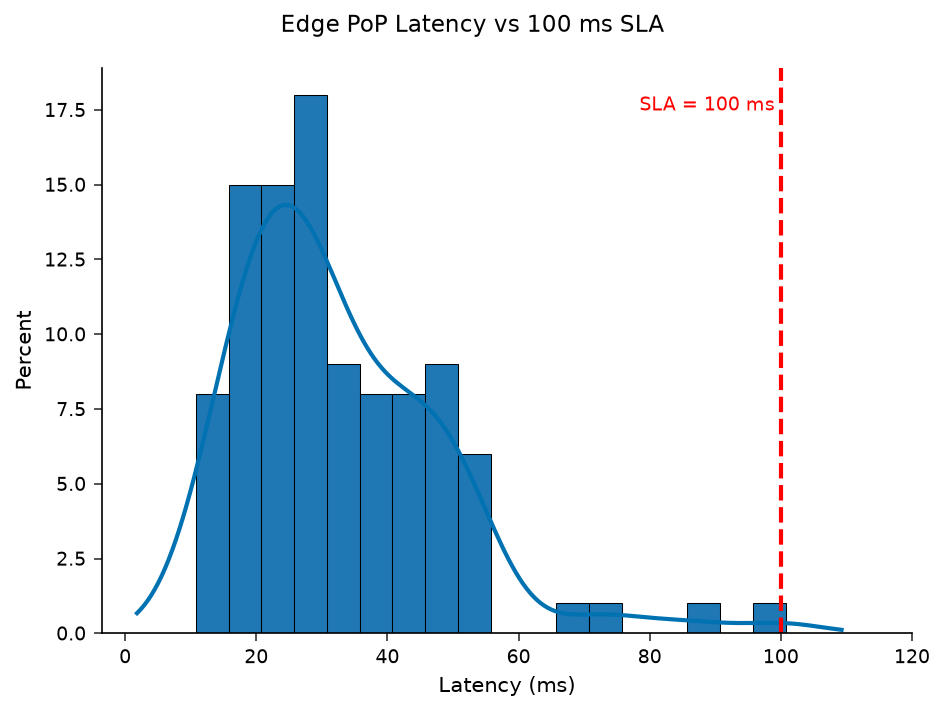

In [3]:
/* --------------------------------------------------------
   Latency distribution with kernel density and the SLA
   threshold drawn in.
   -------------------------------------------------------- */
proc sgplot data=work.latency;
    histogram latency_ms / binwidth=5;
    density latency_ms / type=kernel;
    refline 100 / axis=x lineattrs=(color=red
        pattern=dash thickness=2)
        label='SLA = 100 ms';
    xaxis label='Latency (ms)' max=120;
    yaxis label='Percent';
    title 'Edge PoP Latency vs 100 ms SLA';
run;

The kernel density confirms the right skew that motivates a lognormal fit:
a tall body around 20-35 ms tapering into a long tail toward the SLA line.
Almost all probes land far left of the red 100 ms threshold.

---

                                               SLA Breaches Above 100 ms                                                

                                       Process Capability Indices (USL = 100 ms)                                        

INDEX  VALUE  LOWERCL  UPPERCL
Cpk    1.421        .        .
CPU    1.421        .        .

                                              Fitted Lognormal Parameters                                               

PARAMETER  ESTIMATE
Zeta        3.38771
Sigma      0.451124
Threshold         0



NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: PROC PRINT data=work.cap_idx

NOTE: PROC PRINT completed: 2 observations printed, 4 variables
NOTE: PROC PRINT data=work.cap_lnfit

NOTE: PROC PRINT completed: 3 observations printed, 2 variables


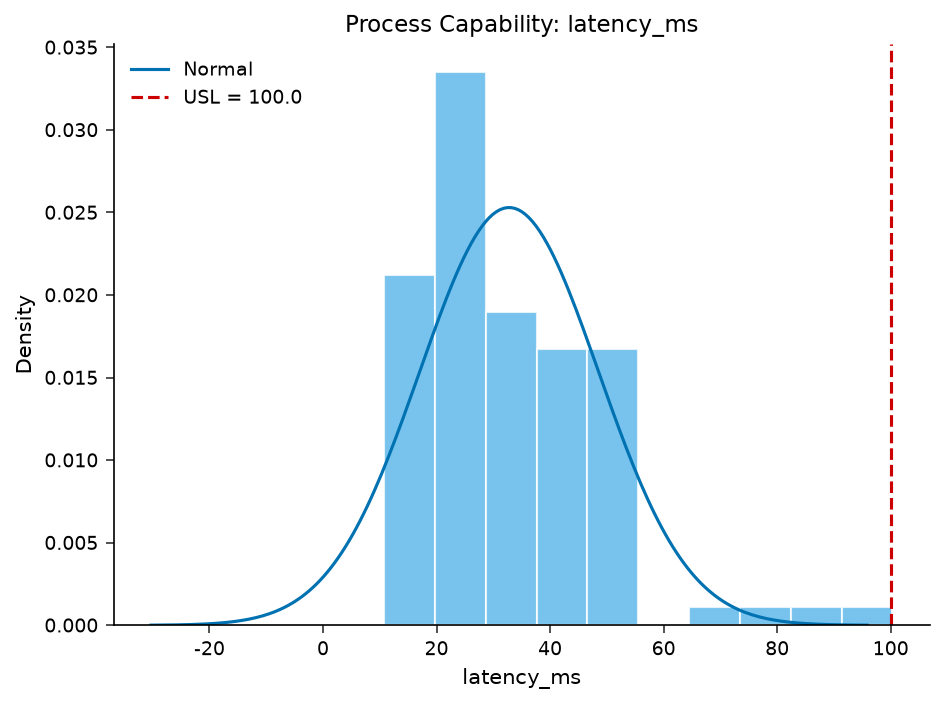

In [4]:
/* --------------------------------------------------------
   Capability against the one-sided SLA: USL = 100 ms.
   Fit a LOGNORMAL distribution and capture the indices and
   fitted parameters as datasets via ODS OUTPUT.
   -------------------------------------------------------- */
proc capability data=work.latency noprint;
    spec usl=100;
    var latency_ms;
    histogram latency_ms / lognormal;
    ods output CapabilityIndices=work.cap_idx
               FittedLognormal=work.cap_lnfit;
run;

proc print data=work.cap_idx noobs;
    title 'Process Capability Indices (USL = 100 ms)';
run;

proc print data=work.cap_lnfit noobs;
    title 'Fitted Lognormal Parameters';
run;

With a one-sided spec the relevant index is the upper capability
**CPU = 1.42**, and `Cpk` equals it (there is no lower limit). A value above
1.33 is the usual bar for an acceptable process, so this PoP is **capable**:
the distance from the process centre to the 100 ms limit is about 4.3 process
standard deviations. The fitted lognormal parameters — **Zeta = 3.388** (log
mean) and **Sigma = 0.451** (log standard deviation) — are the maximum
likelihood estimates on the log scale and back-transform to a median of
exp(3.388) ≈ 29.6 ms, consistent with the observed median above. The
capability histogram below shows the probe data against the 100 ms USL;
the smooth reference curve drawn over the bars is a Normal density for
visual scale, while the capability index itself is computed from the
lognormal fit reported in the parameter table.

---

In [5]:
/* --------------------------------------------------------
   Two-PoP comparison within the 100-observation budget:
   50 probes from a healthy node (EDGE-A) and 50 from a
   congested node (EDGE-B). The same Cpk separates them.
   -------------------------------------------------------- */
data work.lat2;
    call streaminit(42);
    length pop_id $8;
    array mu[2] _temporary_ (3.30 3.65);
    array sg[2] _temporary_ (0.35 0.50);
    do p = 1 to 2;
        if p = 1 then pop_id = 'EDGE-A';
        else pop_id = 'EDGE-B';
        do k = 1 to 50;
            latency_ms = round(
                exp(rand('normal', mu[p], sg[p])), 0.01);
            output;
        end;
    end;
    drop p k;
    format latency_ms 8.2;
run;

proc means data=work.lat2 n mean p95 max maxdec=2;
    class pop_id;
    var latency_ms;
    title 'Latency by PoP';
run;

                                                     Latency by PoP                                                     

                                                  The MEANS Procedure

                                             Analysis Variable : latency_ms

        pop_id            N Obs           Mean      95th Pctl        Maximum
        --------------------------------------------------------------------
        EDGE-A               50          27.38          42.63          43.17
        EDGE-B               50          45.94         114.92         147.28
        --------------------------------------------------------------------



NOTE: DATA work.lat2


NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                                     Latency by PoP                                                     

                                      Capability Index by PoP (EDGE-A then EDGE-B)                                      

INDEX   VALUE  LOWERCL  UPPERCL
Cpk    2.8076        .        .
CPU    2.8076        .        .
Cpk    0.6527        .        .
CPU    0.6527        .        .



NOTE: PROC SORT data=work.lat2

NOTE: Read 100 rows from work.lat2.
NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: PROC PRINT data=work.cap_by_pop

NOTE: PROC PRINT completed: 4 observations printed, 4 variables


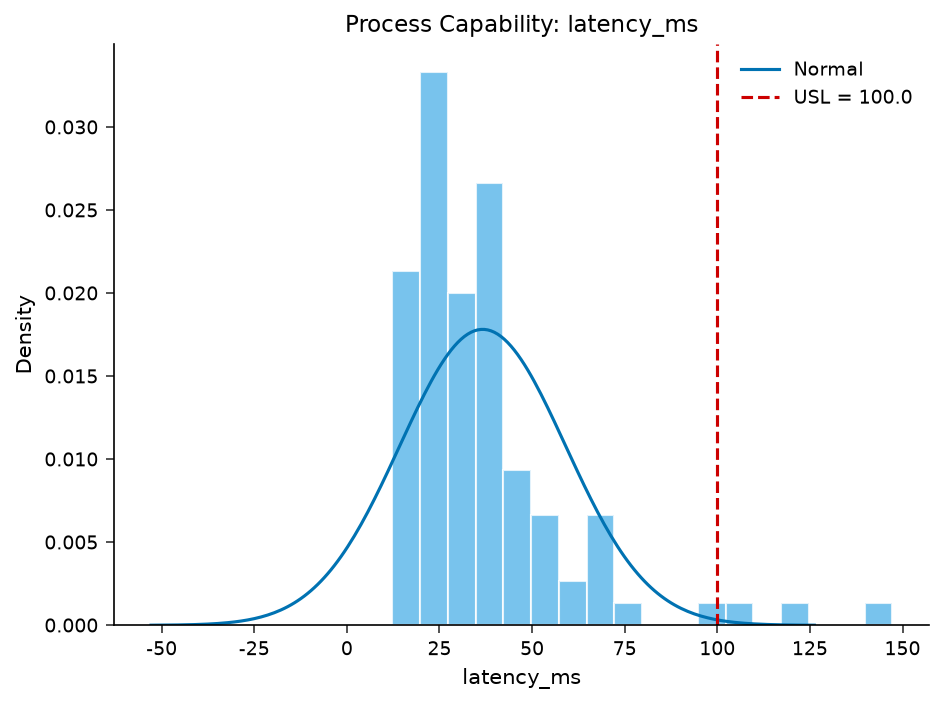

In [6]:
/* --------------------------------------------------------
   Capability index per PoP. BY-group order is EDGE-A then
   EDGE-B, so the first index pair belongs to EDGE-A and the
   second to EDGE-B.
   -------------------------------------------------------- */
proc sort data=work.lat2;
    by pop_id;
run;

proc capability data=work.lat2 noprint;
    by pop_id;
    spec usl=100;
    var latency_ms;
    histogram latency_ms / lognormal;
    ods output CapabilityIndices=work.cap_by_pop;
run;

proc print data=work.cap_by_pop noobs;
    title 'Capability Index by PoP (EDGE-A then EDGE-B)';
run;

### Interpretation

The two PoPs tell opposite capability stories from the same SLA. **EDGE-A**
holds a mean of **27.38 ms** with a 95th percentile of **42.63 ms** and a
maximum of **43.17 ms** — never close to the limit — and posts a
**Cpk of 2.81**, far above the 1.33 acceptance bar. **EDGE-B** runs hotter:
a mean of **45.94 ms**, a 95th percentile of **114.92 ms**, and a maximum of
**147.28 ms**, with probes routinely past the SLA. Its **Cpk falls to 0.65**,
well under 1.0, marking it as **not capable** — the process centre is too
close to (and its tail well beyond) the 100 ms limit.

For a network operations team the index is an actionable triage signal:
EDGE-A is compliant and needs no action, while EDGE-B requires capacity
expansion or routing changes before it can meet the SLA. The lognormal fit
matters here — a normal model would understate the tail risk that drives
EDGE-B's poor capability. The single-PoP analysis earlier (Cpk = 1.42) sits
between these two, illustrating the full range from failing to comfortably
capable that a one-sided latency SLA produces.

---

In [7]:
/* --------------------------------------------------------
   Export the per-PoP capability indices for a NOC dashboard.
   -------------------------------------------------------- */
proc export data=work.cap_by_pop
    outfile='edge_pop_capability.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.cap_by_pop outfile=edge_pop_capability.csv

NOTE: Exported 4 rows to edge_pop_capability.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>